# Prorating Face Values Step 3

Determined a monthly prorated volume for each appropriative water right in step 2 based on the number of superseason days in the month. In this step, a similar method is applied to riparian and pre-1914 statements.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NV_table = pd.read_csv("../Outputs/NV_Full_Dataframe.csv")



### Select only the statements (APPLICATION_NUMBER begins with S)

R code to replicate

```
# returns vector of row indices where APPLICATION_NUMBER starts with S by using regular expression
starts_with_s <- str_extract(NV_df$APPLICATION_NUMBER, "^[S]")
s_rows <- which(!is.na(starts_with_s)) # row indices where APPLICATION_NUMBER starts with S

NV_Statements <- NV_df[s_rows, ]

# select relevant columns
NV_Statements <- NV_Statements |>
  select(APPLICATION_NUMBER, POD_ID, INI_REPORTED_DIV_AMOUNT, INI_REPORTED_DIV_UNIT,
         JAN_MEAN_DIV, FEB_MEAN_DIV, MAR_MEAN_DIV, APR_MEAN_DIV, MAY_MEAN_DIV, JUN_MEAN_DIV,
         JUL_MEAN_DIV, AUG_MEAN_DIV, SEP_MEAN_DIV, OCT_MEAN_DIV, NOV_MEAN_DIV, DEC_MEAN_DIV,
         SUPERSEASON_LENGTH, JAN_COUNT, FEB_COUNT, MAR_COUNT, APR_COUNT, MAY_COUNT, JUN_COUNT,
         JUL_COUNT, AUG_COUNT, SEP_COUNT, OCT_COUNT, NOV_COUNT, DEC_COUNT)
```

In [3]:
# use boolean mask then pandas' str
s_mask = NV_table["APPLICATION_NUMBER"].str.startswith("S", na = False) # look for rows that start w/ S; na = False makes sure missing (NaN) values don't cause errors

NV_Statements = NV_table[s_mask].copy() # apply the mask to directly filter the dataframe

# pandas equivalent of select() in dplyr is to use [] to define a list
columns_to_keep = ["APPLICATION_NUMBER", "POD_ID", "INI_REPORTED_DIV_AMOUNT", "INI_REPORTED_DIV_UNIT",
                   "JAN_MEAN_DIV", "FEB_MEAN_DIV", "MAR_MEAN_DIV", "APR_MEAN_DIV", "MAY_MEAN_DIV", "JUN_MEAN_DIV",
                   "JUL_MEAN_DIV", "AUG_MEAN_DIV", "SEP_MEAN_DIV", "OCT_MEAN_DIV", "NOV_MEAN_DIV", "DEC_MEAN_DIV",
                   "SUPERSEASON_LENGTH", "JAN_COUNT", "FEB_COUNT", "MAR_COUNT", "APR_COUNT", "MAY_COUNT", "JUN_COUNT",
                   "JUL_COUNT", "AUG_COUNT", "SEP_COUNT", "OCT_COUNT", "NOV_COUNT", "DEC_COUNT"]

NV_Statements = NV_Statements[columns_to_keep]

### Add columns to df to begin analysis

R operation

```
NV_Statements <- NV_Statements |>
  add_column(SS_DAILY_AMT = 0)

for (i in 1:nrow(NV_Statements)) {
  NV_Statements$SS_DAILY_AMT[i] = NV_Statements$INI_REPORTED_DIV_AMOUNT[i] / NV_Statements$SUPERSEASON_LENGTH[i]
} # the amount diverted, on average, per superseason day (AF / SS day)
```

In [4]:
NV_Statements["SS_DAILY_AMT"] = 0 # add columns and have the value in all rows be 0

NV_Statements["SS_DAILY_AMT"] = (
    NV_Statements["INI_REPORTED_DIV_AMOUNT"] / NV_Statements["SUPERSEASON_LENGTH"]
)
# pandas aligns the rows of the specified columns then divides element-by-element, eliminating need for a loop and row indexing

### Calculate monthly estimated use

R code to replicate

```
# columns for estimated monthly use
NV_Statements <- NV_Statements |>
  add_column(
    JAN_PRO_AMT = 0, FEB_PRO_AMT = 0, MAR_PRO_AMT = 0, APR_PRO_AMT = 0, MAY_PRO_AMT = 0, JUN_PRO_AMT = 0,
    JUL_PRO_AMT = 0, AUG_PRO_AMT = 0, SEP_PRO_AMT = 0, OCT_PRO_AMT = 0, NOV_PRO_AMT = 0, DEC_PRO_AMT = 0
  )
```
Then, for each month:
```
# JAN
for (i in 1:nrow(NV_Statements)) {
  NV_Statements$JAN_PRO_AMT[i] = NV_Statements$SS_DAILY_AMT[i] * NV_Statements$JAN_COUNT[i]
}
```

Then, replace any NA with 0
```
# Replace NA with zeros to indicate no water usage that month

# JAN
for (i in 1:nrow(NV_Statements)) {
  NV_Statements$JAN_PRO_AMT[i][is.na(NV_Statements$JAN_PRO_AMT[i])] <- 0
}
```

In [5]:
# add columns
NV_Statements[["JAN_PRO_AMT", "FEB_PRO_AMT", "MAR_PRO_AMT", "APR_PRO_AMT", "MAY_PRO_AMT", "JUN_PRO_AMT",
              "JUL_PRO_AMT", "AUG_PRO_AMT", "SEP_PRO_AMT", "OCT_PRO_AMT", "NOV_PRO_AMT", "DEC_PRO_AMT"]] = 0

NV_Statements["JAN_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["JAN_COUNT"]
)

NV_Statements["FEB_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["FEB_COUNT"]
)

NV_Statements["MAR_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["MAR_COUNT"]
)

NV_Statements["APR_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["APR_COUNT"]
)

NV_Statements["MAY_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["MAY_COUNT"]
)

NV_Statements["JUN_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["JUN_COUNT"]
)

NV_Statements["JUL_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["JUL_COUNT"]
)

NV_Statements["AUG_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["AUG_COUNT"]
)

NV_Statements["SEP_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["SEP_COUNT"]
)

NV_Statements["OCT_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["OCT_COUNT"]
)

NV_Statements["NOV_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["NOV_COUNT"]
)

NV_Statements["DEC_PRO_AMT"] = (
    NV_Statements["SS_DAILY_AMT"] * NV_Statements["DEC_COUNT"]
)


cols_to_search = ["JAN_PRO_AMT", "FEB_PRO_AMT", "MAR_PRO_AMT", "APR_PRO_AMT", "MAY_PRO_AMT", "JUN_PRO_AMT",
                  "JUL_PRO_AMT", "AUG_PRO_AMT", "SEP_PRO_AMT", "OCT_PRO_AMT", "NOV_PRO_AMT", "DEC_PRO_AMT"]

NV_Statements[cols_to_search] = NV_Statements[cols_to_search].fillna(0)

### Plotting

In R, made smaller dataframes that were a selection from `NV_Statements`. Then used `pivot_longer` to create a long dataframe to use for plotting.

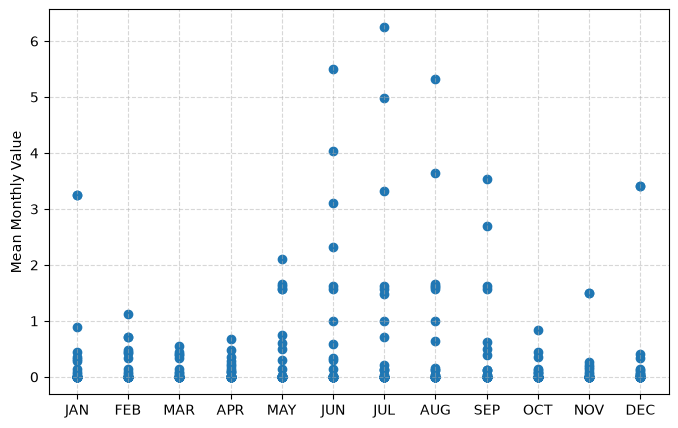

In [6]:
# melt is same as pivot_longer() in R
countDF = pd.melt(
    NV_Statements,
    id_vars = ["APPLICATION_NUMBER", "POD_ID"],
    value_vars = [col for col in NV_Statements.columns if "_COUNT" in col],
    var_name = "MONTH_COUNT",
    value_name = "COUNT"
)

proDF = pd.melt(
    NV_Statements,
    id_vars = ["APPLICATION_NUMBER", "POD_ID"],
    value_vars = [col for col in NV_Statements.columns if "_PRO_AMT" in col],
    var_name = "MONTH_PRORATED",
    value_name = "PRORATED_FACE_VALUE"
)

monthlyDF = pd.melt(
    NV_Statements,
    id_vars = ["APPLICATION_NUMBER", "POD_ID"],
    value_vars = [col for col in NV_Statements.columns if "_MEAN_DIV" in col],
    var_name = "MEAN_MONTHLY",
    value_name = "MEAN_MONTHLY_VALUE"
)

# extract first three uppercase letters for the months
countDF["MONTH"] = countDF["MONTH_COUNT"].str.extract(r"^([A-Z]{3})")[0]
proDF["MONTH"] = countDF["MONTH_COUNT"].str.extract(r"^([A-Z]{3})")[0]
monthlyDF["MONTH"] = countDF["MONTH_COUNT"].str.extract(r"^([A-Z]{3})")[0] # what does the [0] do?

# full join
longDF = pd.merge(countDF, proDF, on = ["APPLICATION_NUMBER", "POD_ID", "MONTH"], how = "outer")
longDF = pd.merge(longDF, monthlyDF, on = ["APPLICATION_NUMBER", "POD_ID", "MONTH"], how = "outer")

month_order = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
               "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

# use ordered months
longDF["MONTH"] = pd.Categorical(longDF["MONTH"], categories = month_order, ordered = True)

longDF = longDF.sort_values("MONTH") # sort so points plot in chronological order

# plot
plt.figure(figsize = (8, 5)) # (x, y) interpreted as (x, y, "inch") - 8 in left to right, 5 inches top to bottom
plt.scatter(longDF["MONTH"], longDF["MEAN_MONTHLY_VALUE"]) # plt.scatter(df[x-axis], df[y-axis])
plt.xlabel("")
plt.ylabel("Mean Monthly Value")
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()

# potentially plot on log scale to more clearly see differences

### Average all the reported and prorated monthly values

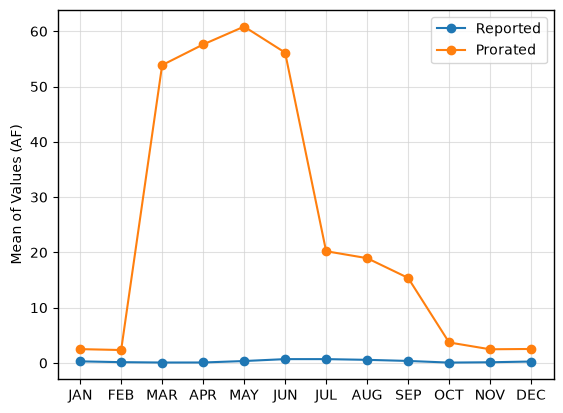

In [8]:
# means for reported values
JAN_MEAN = NV_Statements["JAN_MEAN_DIV"].mean()
FEB_MEAN = NV_Statements["FEB_MEAN_DIV"].mean()
MAR_MEAN = NV_Statements["MAR_MEAN_DIV"].mean()
APR_MEAN = NV_Statements["APR_MEAN_DIV"].mean()
MAY_MEAN = NV_Statements["MAY_MEAN_DIV"].mean()
JUN_MEAN = NV_Statements["JUN_MEAN_DIV"].mean()
JUL_MEAN = NV_Statements["JUL_MEAN_DIV"].mean()
AUG_MEAN = NV_Statements["AUG_MEAN_DIV"].mean()
SEP_MEAN = NV_Statements["SEP_MEAN_DIV"].mean()
OCT_MEAN = NV_Statements["OCT_MEAN_DIV"].mean()
NOV_MEAN = NV_Statements["NOV_MEAN_DIV"].mean()
DEC_MEAN = NV_Statements["DEC_MEAN_DIV"].mean()
MEAN_OF_REPORTED_VALUES = pd.DataFrame({
    "MONTH": ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
              "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"],
    "MEAN_VALUE": [JAN_MEAN, FEB_MEAN, MAR_MEAN, APR_MEAN, MAY_MEAN, JUL_MEAN,
                   JUL_MEAN, AUG_MEAN, SEP_MEAN, OCT_MEAN, NOV_MEAN, DEC_MEAN]
})

# means for prorated values
JAN_MEAN_PRORATED = NV_Statements["JAN_PRO_AMT"].mean()
FEB_MEAN_PRORATED = NV_Statements["FEB_PRO_AMT"].mean()
MAR_MEAN_PRORATED = NV_Statements["MAR_PRO_AMT"].mean()
APR_MEAN_PRORATED = NV_Statements["APR_PRO_AMT"].mean()
MAY_MEAN_PRORATED = NV_Statements["MAY_PRO_AMT"].mean()
JUN_MEAN_PRORATED = NV_Statements["JUN_PRO_AMT"].mean()
JUL_MEAN_PRORATED = NV_Statements["JUL_PRO_AMT"].mean()
AUG_MEAN_PRORATED = NV_Statements["AUG_PRO_AMT"].mean()
SEP_MEAN_PRORATED = NV_Statements["SEP_PRO_AMT"].mean()
OCT_MEAN_PRORATED = NV_Statements["OCT_PRO_AMT"].mean()
NOV_MEAN_PRORATED = NV_Statements["NOV_PRO_AMT"].mean()
DEC_MEAN_PRORATED = NV_Statements["DEC_PRO_AMT"].mean()
MEAN_OF_PRORATED_VALUES = pd.DataFrame({
    "MONTH": ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
              "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"],
    "MEAN_PRO": [JAN_MEAN_PRORATED, FEB_MEAN_PRORATED, MAR_MEAN_PRORATED, APR_MEAN_PRORATED, MAY_MEAN_PRORATED, JUN_MEAN_PRORATED,
                 JUL_MEAN_PRORATED, AUG_MEAN_PRORATED, SEP_MEAN_PRORATED, OCT_MEAN_PRORATED, NOV_MEAN_PRORATED, DEC_MEAN_PRORATED]
})

Means_for_Comparison = pd.DataFrame({
    "MONTH": month_order,
    "MEAN_OF_REPORTED_VALUES": MEAN_OF_REPORTED_VALUES["MEAN_VALUE"],
    "MEAN_OF_PRORATED_VALUES": MEAN_OF_PRORATED_VALUES["MEAN_PRO"]
})

Means_for_Comparison["MONTH"] = pd.Categorical(
    Means_for_Comparison["MONTH"],
    categories = month_order,
    ordered = True
)

Means_for_Comparison = Means_for_Comparison.sort_values("MONTH")

# use melt again
Means_for_Comparison_Long = pd.melt(
    Means_for_Comparison,
    id_vars = ["MONTH"],
    value_vars = ["MEAN_OF_REPORTED_VALUES", "MEAN_OF_PRORATED_VALUES"],
    var_name = "Type",
    value_name = "Value"
)

# make sure months are correctly ordered
Means_for_Comparison_Long["MONTH"] = pd.Categorical(
    Means_for_Comparison_Long["MONTH"],
    categories = month_order,
    ordered = True
)
Means_for_Comparison_Long = Means_for_Comparison_Long.sort_values("MONTH")

# build the plot
types = Means_for_Comparison_Long["Type"].unique()
label_mapping = {
    "MEAN_OF_PRORATED_VALUES": "Prorated",
    "MEAN_OF_REPORTED_VALUES": "Reported"
}

for t in types:
    subset = Means_for_Comparison_Long[Means_for_Comparison_Long["Type"] == t]
    plt.plot(
        subset["MONTH"],
        subset["Value"],
        marker = "o",
        label = label_mapping.get(t, t)
    )

plt.xlabel("")
plt.ylabel("Mean of Values (AF)")
plt.legend(title = "")
plt.grid(True, linestyle = "-", color = "lightgray", alpha = 0.7)
plt.gca().set_facecolor("white")
for spine in plt.gca().spines.values(): # adds border around the plot
    spine.set_color("black")
    spine.set_linewidth(1)

plt.show()